# Telco Customer Churn — Statistical Analysis & Multicollinearity

- **Notebook:** `02_statistical_analysis.ipynb`
- **Phase:** EDA (Part 2 of 4)
- **Previous:** [`01_eda.ipynb`](01_eda.ipynb) — data understanding, distributions, target relationships
- **Next:** [`03_business_analysis.ipynb`](03_business_analysis.ipynb) — segmentation and business questions

## Scope
This notebook covers Q14–Q15 of the EDA plan:
- **Q14:** Correlation matrix of numerical features and multicollinearity assessment
- **Q15:** Phik (φK) matrix across all feature types for unified feature-target ranking

## Key findings carried forward from `01_eda.ipynb`
- Dataset: 7,043 customers, 21 features, 26.6% churn rate
- 11 rows had blank TotalCharges (tenure=0 customers), imputed as 0
- Top 5 categorical features by Cramér's V: Contract (0.41), OnlineSecurity (0.35), TechSupport (0.34), InternetService (0.32), PaymentMethod (0.30)
- Multicollinearity concern flagged for OnlineSecurity / TechSupport (near-tied V values)

In [11]:
# Imports
import sys
from pathlib import Path

# Get project root
PROJECT_ROOT = Path.cwd().parent

# Add to python path
sys.path.append(str(PROJECT_ROOT))

# Raw data folder
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
# File path
data_file_path = RAW_DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Figure directory
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st

from src.scripts.data import load_clean_telco_data
from src.scripts import utils

# set display max columns
pd.set_option("display.max_columns",None)

# Set default figure size and dpi
plt.rcParams['figure.dpi'] = 300

In [2]:
# Load Dataset
df = load_clean_telco_data(data_path=data_file_path)
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Q14. Correlation matrix of numerical features and multicollinearity assessment

#### Numerical Features — `Tenure`, `MonthlyCharges`, `TotalCharges`

**Predictions based on previous analysis**:

- `Tenure` ↔ `TotalCharges`: *very high positive correlation* (**~0.83**), because `TotalCharges ≈ Tenure × MonthlyCharges`. Established in Q10.
- `MonthlyCharges` ↔ `TotalCharges`: *moderate positive correlation*. `Higher monthly bill → faster accumulation of total charges`, but the relationship is muddied by tenure.
- `tenure` ↔ `MonthlyCharges`: *weak positive correlation*. The longer someone has been a customer, the more services they've added over time (slow grade-up), but it's a much weaker relationship.

                Tenure  MonthlyCharges  TotalCharges
Tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


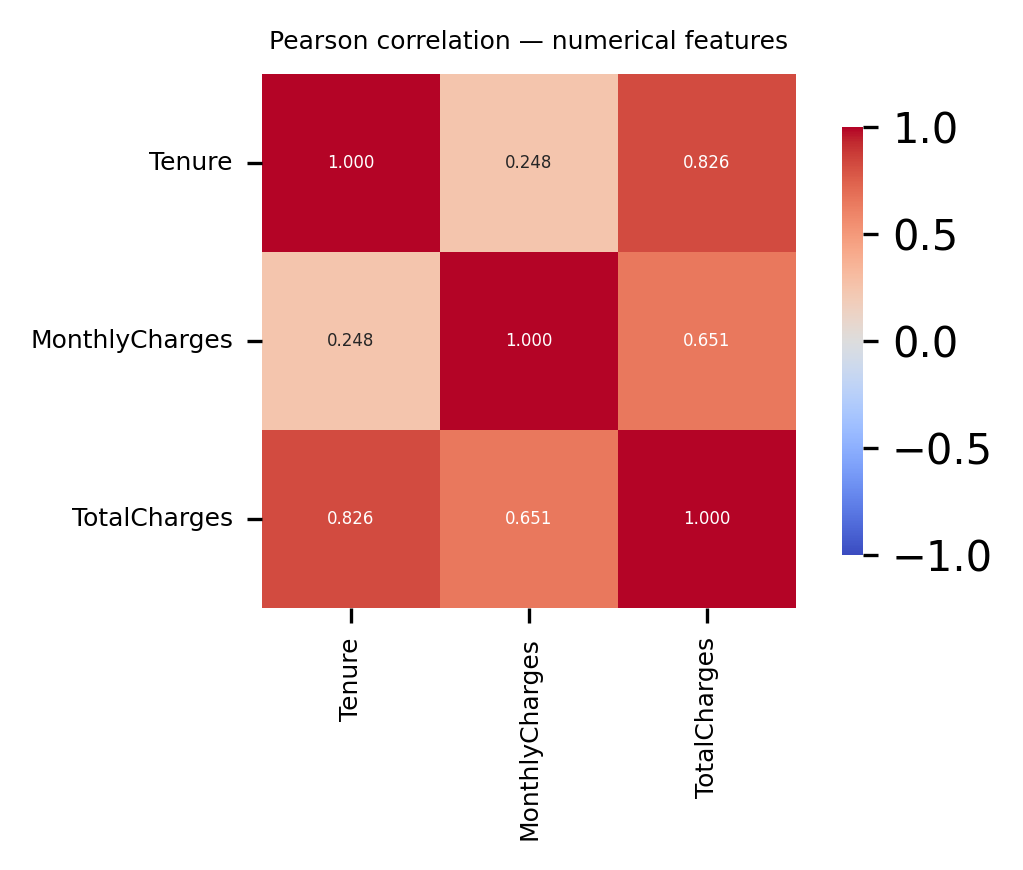

In [22]:
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Correlation matrix
corr_matrix = df[numerical_cols].corr()
print(corr_matrix.round(3))

# Heatmap visualization
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', square=True,
            annot_kws={"size": 4}, cbar_kws={'shrink': 0.8})
plt.title('Pearson correlation — numerical features', fontsize=6)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_correlation_matrix_numerical.png", dpi=300)
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[numerical_cols].values
vif_data = pd.DataFrame({
    'feature': numerical_cols,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif_data)

          feature       VIF
0          Tenure  6.332328
1  MonthlyCharges  3.355660
2    TotalCharges  8.075070


- **Pairwise correlations** (Pearson, numerical features only):

|                | tenure | MonthlyCharges | TotalCharges |
|----------------|--------|----------------|--------------|
| tenure         | 1.000  | 0.248          | `0.826`      |
| MonthlyCharges | 0.284  | 1.000          | `0.651`      |
| TotalCharges   | `0.826`| `0.651`        | 1.000        |

- Two correlations stand out: `0.826` & `0.651`

1. `Tenure` ↔ `TotalCharges` = 0.**83** — very strong positive correlation. This is mechanical: `TotalCharges` accumulates monthly, so longer tenure necessarily means higher `TotalCharges`. This was visually evident in Q10's scatter plot.

2. `MonthlyCharges` ↔ `TotalCharges` = **0.65** — moderate positive correlation. Higher monthly bills produce faster accumulation, but tenure is the dominant driver.

3. `Tenure` ↔ `MonthlyCharges` = **0.25** — weak positive corrlation. Customers add services slowly over time, but this is a much weaker effect than the cumulative billing relationship.

- **VIF(Variance Inflation Factor) results**:

1. `Tenure`: 6.33
2. `MonthlyCharges`: 3.36
3. `TotalCharges`: 8.08

- **Implications for modeling**:
* For **logistic regression** (which assumes feature independence for stable coefficient estimates), the `Tenure` ↔ `TotalCharges` relationship is a concern. Including all three features will likely produce:
    * Unstable coefficients with potential sign flips across random seeds.
    * Inflated standard errors, making individual coefficients statistically insignificant despite the model fitting well overall.
    * Reduced interpretability — the "effect of `TotalCharges` holding tenure constant" is not a meaningful question in this data.

- **Planned mitigation**:
    - **Option A (recommended baseline)**: Drop `TotalCharges` from the logistic regression. Keep `Tenure` and `MonthlyCharges` as the two independent numerical predictors.
    - **Option B (worth experimenting)**: Replace `TotalCharges` with a derived `avg_monthly_spend = TotalCharges / max(tenure, 1)` feature, which captures spending intensity without redundancy.
    - **Option C**: For the final model, use a regularized variant (Ridge or Elastic Net) which handles correlated features gracefully.

- For **tree-based models** (*Random Forest*, *XGBoost*), multicollinearity does not degrade predictive accuracy. However, it does distort feature importance — the importance of `Tenure` gets split between `Tenure` and `TotalCharges`. SHAP analysis (planned for Phase 2 evaluation) will reveal the true individual contributions.

- **Carried forward to Q22**: Decision on whether to drop `TotalCharges`, replace it with `avg_monthly_spend`, or keep all three with regularization will be tested empirically in Phase 2 modeling.